Classification Accuracy: 0.6207
              precision    recall  f1-score   support

           0       0.64      0.55      0.59        29
           1       0.61      0.69      0.65        29

    accuracy                           0.62        58
   macro avg       0.62      0.62      0.62        58
weighted avg       0.62      0.62      0.62        58


Success Rates by Consistency Group:
  consistency_group  is_success
0  High consistency         0.5
1   Low consistency         0.5
Correlation between Consistency and Views by Segment:
     Segment  Consistency_Correlation      Avg_Views
0  education                -0.270761  162633.165517
1    podcast                -0.316342  163572.689655

Probability of 'Hit' Video (Views > Median):
When 'On Time' (±1 day of avg): 55.00%
When 'Off Schedule': 49.53%

Segment Profile:
           Avg Engagement  Avg Interval  Consistency
segment                                             
education        0.080108      8.372414     0.147321
podca

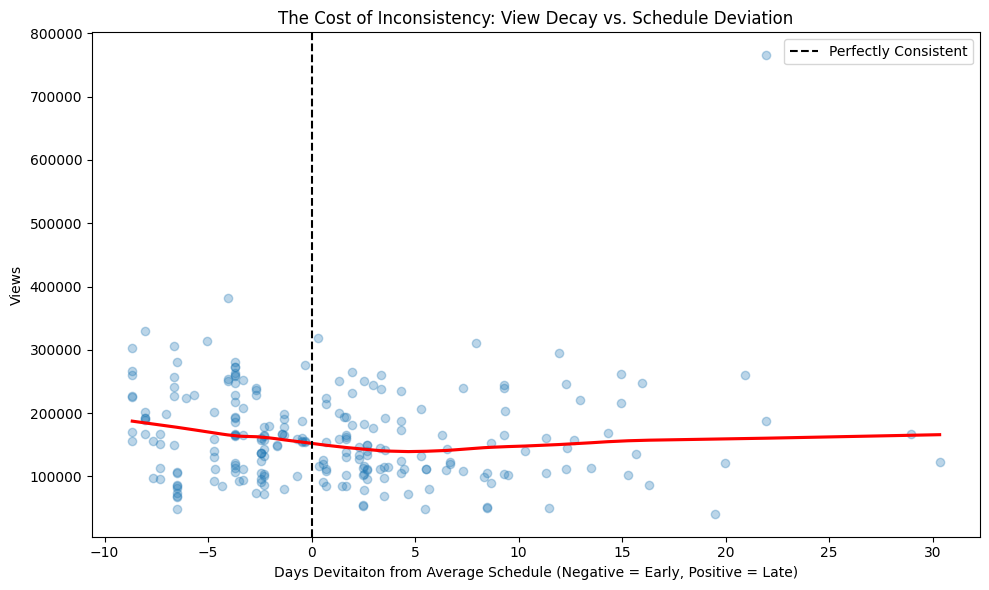

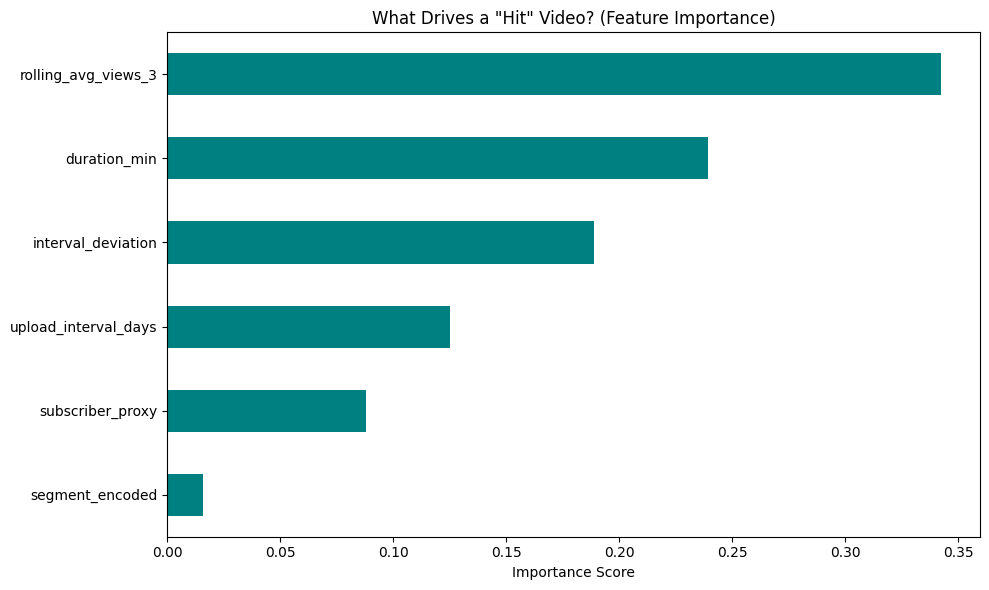

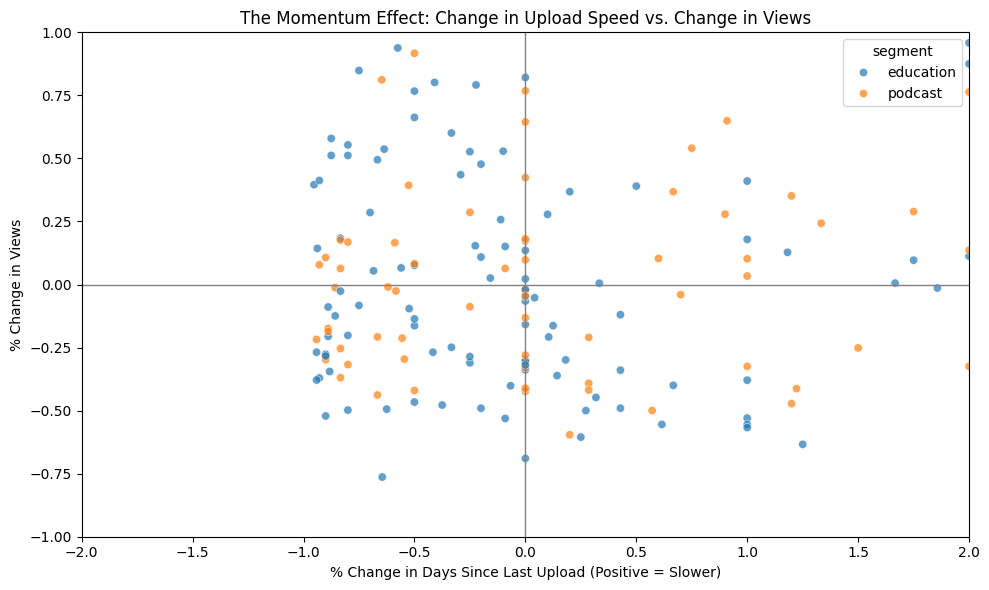

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder


df = pd.read_csv('youtube_consistency_dataset (2).csv')


creator_medians = df.groupby('creator')['views'].transform('median')
df['is_success'] = (df['views'] > creator_medians).astype(int)


df['interval_deviation'] = df['upload_interval_days'] - df['base_interval_days']


ml_df = df.dropna(subset=['upload_interval_days', 'interval_deviation']).copy()


le_segment = LabelEncoder()
ml_df['segment_encoded'] = le_segment.fit_transform(ml_df['segment'])


features = [
    'upload_interval_days',
    'interval_deviation',
    'duration_min',
    'subscriber_proxy',
    'segment_encoded',
    'rolling_avg_views_3'
]

X = ml_df[features]
y = ml_df['is_success']


from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)


clf = RandomForestClassifier(n_estimators=200, max_depth=5, random_state=42)
clf.fit(X_train, y_train)


y_pred = clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Classification Accuracy: {accuracy:.4f}")
print(classification_report(y_test, y_pred))


plt.figure(figsize=(10, 6))
sns.regplot(data=ml_df, x='interval_deviation', y='views', scatter_kws={'alpha':0.3}, line_kws={'color':'red'}, lowess=True)
plt.axvline(0, color='black', linestyle='--', label='Perfectly Consistent')
plt.title('The Cost of Inconsistency: View Decay vs. Schedule Deviation')
plt.xlabel('Days Devitaiton from Average Schedule (Negative = Early, Positive = Late)')
plt.ylabel('Views')
plt.legend()
plt.tight_layout()
plt.savefig('consistency_decay_plot.png')


feat_importances = pd.Series(clf.feature_importances_, index=features).sort_values(ascending=True)
plt.figure(figsize=(10, 6))
feat_importances.plot(kind='barh', color='teal')
plt.title('What Drives a "Hit" Video? (Feature Importance)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('success_drivers.png')


success_rates = ml_df.groupby('consistency_group')['is_success'].mean().reset_index()
print("\nSuccess Rates by Consistency Group:")
print(success_rates)

segments = ml_df['segment'].unique()
segment_analysis = []

for seg in segments:
    seg_data = ml_df[ml_df['segment'] == seg]
    corr = seg_data['consistency_index'].corr(seg_data['views'])
    avg_views = seg_data['views'].mean()
    segment_analysis.append({'Segment': seg, 'Consistency_Correlation': corr, 'Avg_Views': avg_views})

segment_df = pd.DataFrame(segment_analysis)
print("Correlation between Consistency and Views by Segment:")
print(segment_df)


ml_df = ml_df.sort_values(['creator', 'upload_date'])
ml_df['view_pct_change'] = ml_df.groupby('creator')['views'].pct_change()
ml_df['interval_pct_change'] = ml_df.groupby('creator')['upload_interval_days'].pct_change()

plt.figure(figsize=(10, 6))
sns.scatterplot(data=ml_df, x='interval_pct_change', y='view_pct_change', hue='segment', alpha=0.7)
plt.axhline(0, color='gray', lw=1)
plt.axvline(0, color='gray', lw=1)
plt.title('The Momentum Effect: Change in Upload Speed vs. Change in Views')
plt.xlabel('% Change in Days Since Last Upload (Positive = Slower)')
plt.ylabel('% Change in Views')
plt.xlim(-2, 2)
plt.ylim(-1, 1)
plt.tight_layout()
plt.savefig('momentum_effect.png')


ml_df['on_time'] = (abs(ml_df['interval_deviation']) <= 1).astype(int) # Within 1 day of average
on_time_success = ml_df.groupby('on_time')['is_success'].mean()

print("\nProbability of 'Hit' Video (Views > Median):")
print(f"When 'On Time' (±1 day of avg): {on_time_success[1]:.2%}")
print(f"When 'Off Schedule': {on_time_success[0]:.2%}")


summary_table = ml_df.groupby('segment').agg({
    'engagement_rate': 'mean',
    'upload_interval_days': 'mean',
    'consistency_index': 'mean'
}).rename(columns={'engagement_rate': 'Avg Engagement', 'upload_interval_days': 'Avg Interval', 'consistency_index': 'Consistency'})

print("\nSegment Profile:")
print(summary_table)